# Модель для прогнозирования оттока клиентов для сервиса доставки кофе


# Описание задачи


На рынке доставки кофе высокая конкуренция, поэтому привлечение нового клиента обходится в 5–7 раз дороже, чем удержание существующего. В последние месяцы Happy Beans Coffee столкнулись с проблемой: каждый месяц сервис теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку. Из-за этого также неэффективно расходуется маркетинговый бюджет: он «работает вхолостую», не обеспечивая прироста клиентской базы.

Прогнозирование оттока (англ. churn prediction) — это ключевой инструмент бизнеса, который повышает рентабельность. С его помощью бизнес с высокой вероятностью определит, какие клиенты планируют уйти в следующем месяце. А зная это, можно кое-что сделать:
Принять меры по удержанию (англ. retention) клиентов: точечно работать с теми, кто потенциально готов отказаться от услуг компании. Для этого можно предложить покупателям персональные скидки, промокоды и специальные акции.
Оптимизировать бюджет: снизить расходы на маркетинг и перенаправить ресурсы на целевые рекламные кампании для удержания клиентов.
Повысить прогнозируемость: точнее планировать будущие доходы (англ. revenue forecasting) и понимать ценность клиентской базы (англ. Customer Lifetime Value, LTV).


# Описание данных


Признаки в датасете  
**user_id** — идентификатор пользователя.  
**days_since_last_order** — количество дней, прошедших с последнего заказа.  
**order_frequency_month** — среднее число заказов в месяц.  
**order_frequency_week** — среднее число заказов в неделю.  
**avg_order_value** — средний чек, в рублях.  
**median_order_value** — медианный чек, в рублях.  
**total_spent_last_month** — сумма заказов за последний месяц.  
**total_spent_last_week** — сумма заказов за последнюю неделю.  
**discount_usage_rate** — доля заказов со скидкой за последний месяц.  
**last_coffee_type** — сорт кофе, купленный пользователем в последний раз на момент сбора данных.  
**preferred_roast** — предпочитаемый тип обжарки.  
**milk_preference** — предпочитаемый тип молока.  
**seasonal_menu_tried** — отметка о том, пробовал ли пользователь новейшее сезонное меню.  
**coffee_bean_origin** — страна происхождения зерна.  
**last_drink_size** — размер последнего заказа, совершённого на момент сбора данных.  
**subscription_status** — тип подписки пользователя.  
**app_opens_per_week** — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.  
**notifications_enabled** — включены ли у пользователя уведомления.  
**review_rating_last_10** — средняя оценка последних на момент сбора данных десяти заказов клиента.  
**review_rating_last_1** — оценка последнего на момент сбора данных заказа клиента.  
**app_crashes_last_month** — сколько раз приложение зависало за последний месяц.  
**seasons** — текущее время года.  
**days_since_last_promo** — сколько дней прошло с последнего использования акции или промокода.  
**phone_type** — тип устройства, с которого пользователь чаще всего совершал покупки.  
**coffee_preference_change** — менялись ли вкусовые предпочтения пользователя.  
**geo_id** — идентификатор региона пользователя.  
**churn** — перестал ли пользователь пользоваться сервисом.


# План работы


## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, FunctionTransformer, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
                             roc_auc_score, confusion_matrix, 
                             roc_curve, precision_recall_curve,average_precision_score)

from IPython.display import display

import joblib

from IPython.display import display
!pip install phik -q
from phik import phik_matrix
RANDOM_STATE = 42

df = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep = ',', decimal=".")

display(df.head(10))

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,...,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,...,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,...,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,...,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


## Этап 2. Первичный анализ данных



2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.

   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.


> -Всего 10450 строк данных.  
-Видно что в данных довольно много стобцов с пропусками.   
-В целевой переменной нет пропусков, это хорошо.  
-Типы данных соответсвуют своим столбцам.


In [3]:
print('Количество ушедших пользователей')
print(df[df['churn'] == 1].shape)
print(round(df[df['churn'] == 1].shape[0] / df['churn'].count(),3),'% Процент ушедших')
print('Количество оставшихся пользователей')
print(df[df['churn'] == 0].shape)
print(round(df[df['churn'] == 0].shape[0] / df['churn'].count(),3),'% Процент оставшихся')

Количество ушедших пользователей
(629, 27)
0.06 % Процент ушедших
Количество оставшихся пользователей
(9821, 27)
0.94 % Процент оставшихся


> -Наблюдаем дисбаланс данных всего 6% ушедших пользователей


>На раннем этапе анализа можно сказать что точно будем отказываться от стобца user_id чтобы он не мешал про обучении модели  
оrder_frequency_week и total_spent_last_week - считаю данные избыточными так как есть данные за месяц  
avg_order_value или median_order_value - нужен только один признак, удалим на основе корреляции
last_coffee_type, preferred_roast, milk_preference, seasonal_menu_tried,coffee_bean_origin,last_drink_size, seasons, phone_type,  - Давольно странные признаки у которых может быть потенциал, но не в данной задаче
Остальные столбцы я бы проверил на корреляции и на будущем этапе уже бы отсеивал


In [4]:
print(df.isnull().sum())

user_id                       0
days_since_last_order       945
order_frequency_month       600
order_frequency_week        388
avg_order_value             583
median_order_value          831
total_spent_last_month      294
total_spent_last_week       944
discount_usage_rate         397
last_coffee_type            258
preferred_roast             116
milk_preference             668
seasonal_menu_tried         989
coffee_bean_origin          682
last_drink_size             504
subscription_status         938
app_opens_per_week          896
notifications_enabled       537
review_rating_last_10       693
review_rating_last_1        857
app_crashes_last_month      721
seasons                     679
days_since_last_promo       731
phone_type                  336
coffee_preference_change    610
geo_location                110
churn                         0
dtype: int64


>Стратегия обработки пропусков будет такой - для числовых данных - заполнение средним или медианой  
Категориальыне - заполнение самым популярным
Бинарные - заполнить всё 0 будет обозначаться как - Нет


In [5]:
cat_columns = ['last_coffee_type','preferred_roast','milk_preference',
               'seasonal_menu_tried','coffee_bean_origin','last_drink_size',
               'subscription_status','notifications_enabled','app_crashes_last_month',
              'seasons', 'phone_type','coffee_preference_change','geo_location']
display(df[cat_columns].head())

,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,notifications_enabled,app_crashes_last_month,seasons,phone_type,coffee_preference_change,geo_location
0,blend,light,almond,NaN,vietnam,large,pro,1.0,NaN,summer,android,0.0,geo_75
1,arabica,light,whole,1.0,guatemala,medium,none,1.0,0.0,autumn,ios,0.0,geo_95
2,arabica,medium,oat,1.0,guatemala,small,premium,1.0,0.0,spring,web,1.0,geo_25
3,robusta,medium,skim,0.0,brazil,medium,none,1.0,0.0,summer,android,0.0,geo_2
4,robusta,dark,almond,1.0,colombia,medium,none,0.0,1.0,winter,ios,0.0,geo_19


>Категориальные признаки которые идут как string нужно закодировать  
Бинарные признаки оставляем как есть


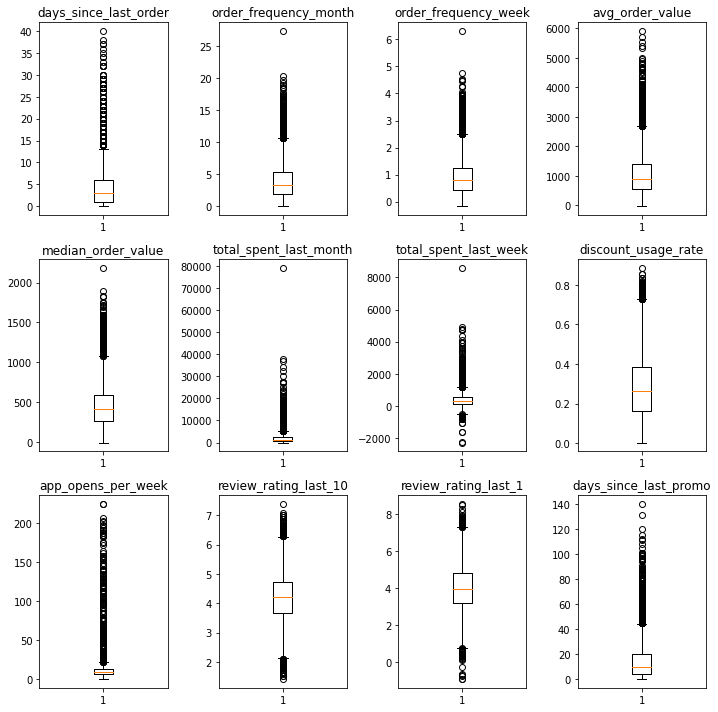

In [6]:
num_columns = ['days_since_last_order','order_frequency_month','order_frequency_week',
               'avg_order_value','median_order_value','total_spent_last_month','total_spent_last_week',
               'discount_usage_rate','app_opens_per_week','review_rating_last_10','review_rating_last_1',
               'days_since_last_promo']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10,10))
axes = axes.flatten()  

for idx, column in enumerate(num_columns):
    axes[idx].boxplot(df[column].dropna())
    axes[idx].set_title(column)
plt.tight_layout()
plt.show()

>Выбросы есть в каждом числовом признаке в дальнейшем скорее всего эти признаки преобразуем с помощью log или sqrt


interval columns not set, guessing: ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change', 'churn']


/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable user_id is large: 10450. Are you sure this is not an interval variable? Analysis for pairs of variables including user_id can be slow.
  warnings.warn(


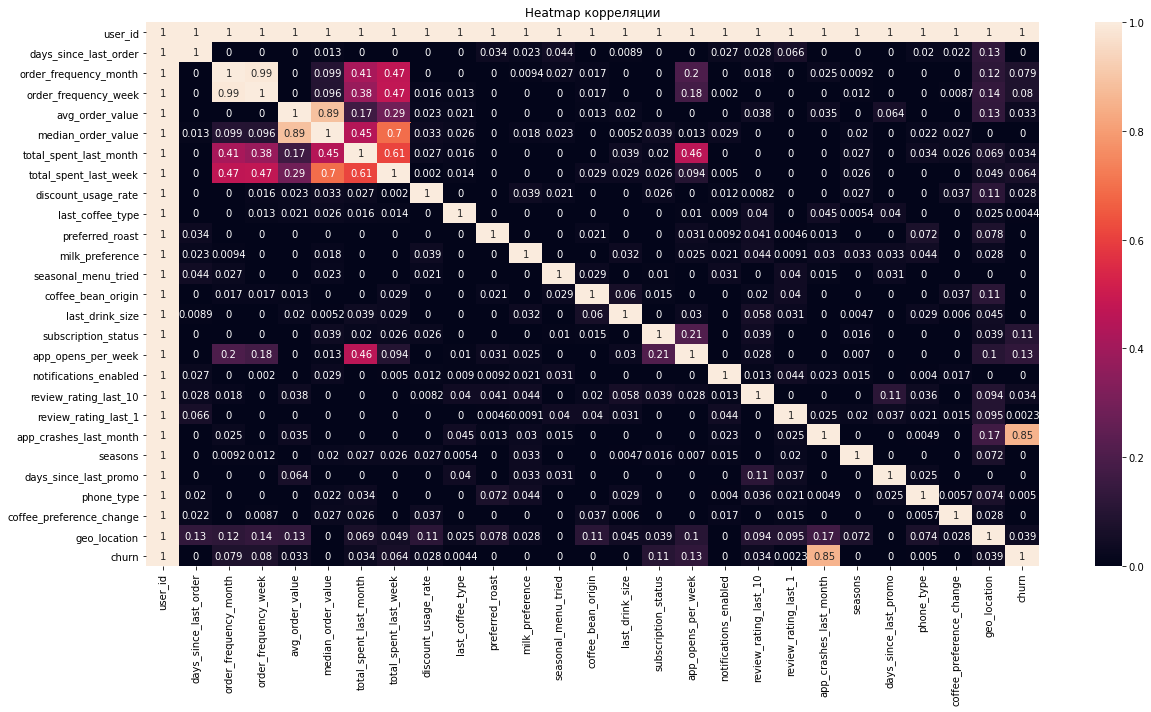

In [7]:
phik_df = df.phik_matrix()
plt.figure(figsize=(20,10))
sns.heatmap(phik_df, annot=True)
plt.title('Heatmap корреляции')
plt.show()

interval columns not set, guessing: ['order_frequency_month', 'avg_order_value', 'total_spent_last_month', 'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month', 'churn']


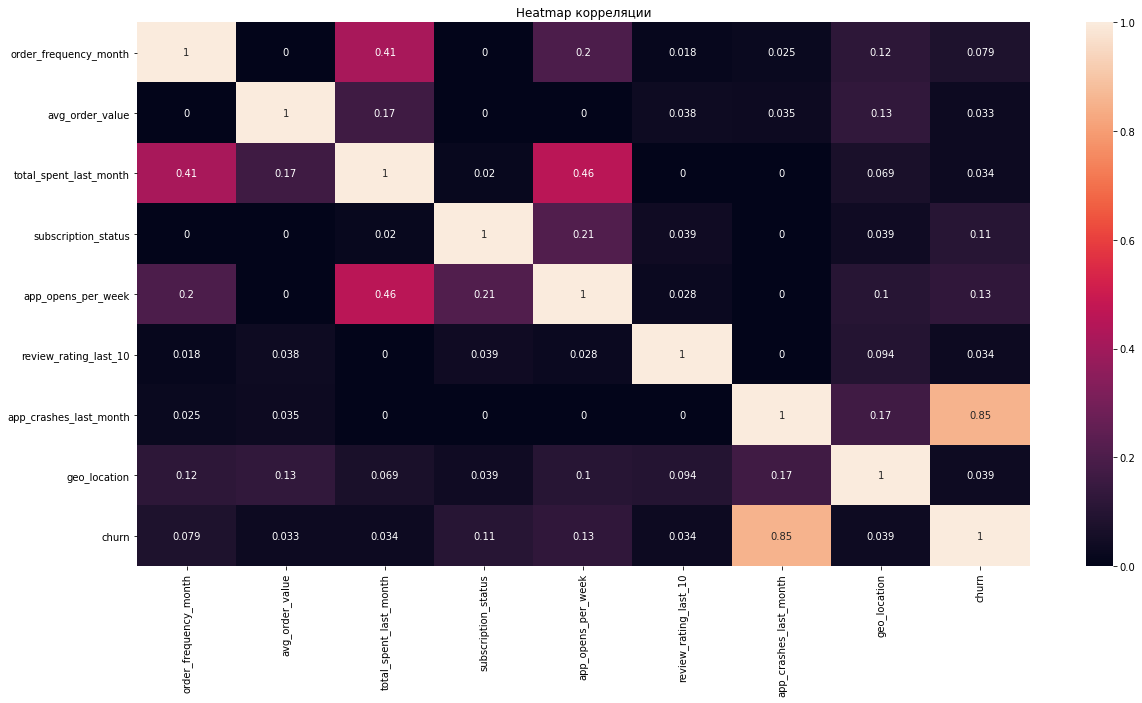

In [8]:
df = df.drop(columns=['user_id','median_order_value','preferred_roast','milk_preference','seasonal_menu_tried',
                      'coffee_bean_origin','last_drink_size','notifications_enabled','last_coffee_type',
                      'review_rating_last_1','seasons','days_since_last_promo','phone_type','coffee_preference_change',
                      'days_since_last_order','order_frequency_week','total_spent_last_week','discount_usage_rate'])
phik_df = df.phik_matrix()
plt.figure(figsize=(20,10))
sns.heatmap(phik_df, annot=True)
plt.title('Heatmap корреляции')
plt.show()

In [9]:
df.describe()

,order_frequency_month,avg_order_value,total_spent_last_month,app_opens_per_week,review_rating_last_10,app_crashes_last_month,churn
count,9850.000000,9867.000000,10156.000000,9554.000000,9757.000000,9729.000000,10450.000000
mean,4.025666,1063.741207,1946.132979,11.330895,4.206709,1.013362,0.060191
std,2.826144,707.713396,2370.619590,14.528887,0.782212,1.010342,0.237852
min,0.011046,-32.075932,-43.716463,0.000000,1.415526,0.000000,0.000000
25%,1.937767,552.898663,629.680382,6.313628,3.675543,0.000000,0.000000
50%,3.381094,898.643524,1300.409757,9.228383,4.203555,1.000000,0.000000
75%,5.439363,1406.332153,2481.650495,12.726649,4.717292,2.000000,0.000000
max,27.389318,5901.965278,79298.849570,224.587876,7.384425,7.000000,1.000000


>Выводы анализа данных: 
-Сильный дисбаланс классов: 6% (629) — churn=1, 94% (9821) — churn=0.  
-Пропуски присутствуют во многих столбцах (от 116 до 989 пропусков). В дальнейшем будут заполнены через SimpleImputer  
-Были удалены признаки с низкой корреляцией и признаки добавляющие шума (сложности) модели.  
-Выбросы - в числовых признаках присутствует весомое количество признаков. Стратегия сглаживания будет через sqrt.  
-Категориальные признаки в дальнейшем будут закодированны.  
-Замечена высокая корреляция целевой переменной с признаком ошибок в приложении


## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.


In [10]:

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)


num_cols = ['order_frequency_month', 'avg_order_value', 'total_spent_last_month', 
            'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month']
cat_cols = ['subscription_status', 'geo_location']


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

>Данные разделены на train/test (80/20).  
Созданы пайплайны для обработки пропусков, масштабирования числовых признаков и кодирования категориальных.  
Категориальные признаки обработаны через OneHotEncoder, числовые - через SimpleImputer и StandardScaler.


## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.


In [11]:

dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)


dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', dummy_model)
])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dummy_scores = cross_validate(
    dummy_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=['f1', 'precision', 'recall', 'roc_auc', 'average_precision'],
    return_train_score=True
)


print("БАЗОВАЯ МОДЕЛЬ (DummyClassifier):")
print(f"F1: {dummy_scores['test_f1'].mean():.4f} (+/- {dummy_scores['test_f1'].std():.4f})")
print(f"Precision: {dummy_scores['test_precision'].mean():.4f} (+/- {dummy_scores['test_precision'].std():.4f})")
print(f"Recall: {dummy_scores['test_recall'].mean():.4f} (+/- {dummy_scores['test_recall'].std():.4f})")
print(f"ROC-AUC: {dummy_scores['test_roc_auc'].mean():.4f} (+/- {dummy_scores['test_roc_auc'].std():.4f})")
print(f"PR-AUC: {dummy_scores['test_average_precision'].mean():.4f} (+/- {dummy_scores['test_average_precision'].std():.4f})")


БАЗОВАЯ МОДЕЛЬ (DummyClassifier):
F1: 0.0621 (+/- 0.0117)
Precision: 0.0607 (+/- 0.0115)
Recall: 0.0636 (+/- 0.0118)
ROC-AUC: 0.5003 (+/- 0.0063)
PR-AUC: 0.0603 (+/- 0.0009)


>Базовая модель DummyClassifier показала низкие метрики (F1=0.0621, PR-AUC=0.0603), что ожидаемо для случайного классификатора и подтверждает дисбаланс данных.


## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.


In [12]:
def create_features_safe(X):
    X = X.copy()
    X['sqrt_order_freq'] = np.sqrt(np.maximum(X['order_frequency_month'] + 1, 0))
    X['sqrt_total_spent'] = np.sqrt(np.maximum(X['total_spent_last_month'] + 1, 0))
    X['sqrt_app_opens'] = np.sqrt(np.maximum(X['app_opens_per_week'] + 1, 0))
    X['sq_app_crashes'] = X['app_crashes_last_month'] ** 2
    X['sq_review_rating'] = X['review_rating_last_10'] ** 2
    X['spent_per_order'] = X['total_spent_last_month'] / (X['order_frequency_month'] + 1e-10)
    X['crashes_per_open'] = X['app_crashes_last_month'] / (X['app_opens_per_week'] + 1e-10)
    X['value_to_review'] = X['avg_order_value'] * X['review_rating_last_10']
    X['high_crashes'] = (X['app_crashes_last_month'] > 2).astype(int)
    X['low_review'] = (X['review_rating_last_10'] < 3).astype(int)
    X['no_spent_last_month'] = (X['total_spent_last_month'] <= 0).astype(int)
    return X

X_train_new = create_features_safe(X_train)
X_test_new = create_features_safe(X_test)

num_cols_new = num_cols + ['sqrt_order_freq', 'sqrt_total_spent', 'sqrt_app_opens', 
                          'sq_app_crashes', 'sq_review_rating', 'spent_per_order',
                          'crashes_per_open', 'value_to_review', 'high_crashes',
                          'low_review', 'no_spent_last_month']

In [13]:
num_pipeline_new = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline_fixed = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor_new_fixed = ColumnTransformer([
    ('num', num_pipeline_new, num_cols_new),
    ('cat', cat_pipeline_fixed, cat_cols)
])

In [14]:
logreg_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')
logreg_pipeline_new = Pipeline([
    ('preprocessor', preprocessor_new_fixed),
    ('model', logreg_model)
])

logreg_new_scores = cross_validate(
    logreg_pipeline_new,
    X_train_new,
    y_train,
    cv=cv,
    scoring=['f1', 'precision', 'recall', 'roc_auc', 'average_precision']
)

print("Модель с новыми признаками:")
print(f"F1: {logreg_new_scores['test_f1'].mean():.4f}")
print(f"PR-AUC: {logreg_new_scores['test_average_precision'].mean():.4f}")

Модель с новыми признаками:
F1: 0.4895
PR-AUC: 0.6732


In [15]:
logreg_pipeline_new.fit(X_train_new, y_train)

encoder = logreg_pipeline_new.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
subscription_cats = encoder.categories_[0]
geo_cats = encoder.categories_[1]

subscription_features = [f'subscription_{cat}' for cat in subscription_cats]
geo_features = [f'geo_{cat}' for cat in geo_cats]
cat_features = subscription_features + geo_features

feature_names = num_cols_new + cat_features

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logreg_pipeline_new.named_steps['model'].coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Топ-10 важных признаков:")
display(coef_df.head(10))

significant_features = coef_df[abs(coef_df['coefficient']) > 0.5]['feature'].tolist()
num_cols_significant = [col for col in num_cols_new if col in significant_features]

cat_cols_significant = []
for feature in significant_features:
    if 'subscription_' in feature:
        cat_cols_significant.append('subscription_status')
    elif 'geo_' in feature:
        cat_cols_significant.append('geo_location')

cat_cols_significant = list(set(cat_cols_significant))

preprocessor_final = ColumnTransformer([
    ('num', num_pipeline_new, num_cols_significant),
    ('cat', cat_pipeline_fixed, cat_cols_significant)
])

train_cols = num_cols_significant + cat_cols_significant

Топ-10 важных признаков:


,feature,coefficient
73,geo_geo_56,2.311216
8,sqrt_app_opens,2.290066
96,geo_geo_77,2.282046
93,geo_geo_74,2.049726
48,geo_geo_33,1.976738
119,geo_geo_98,-1.917741
60,geo_geo_44,1.890533
24,geo_geo_11,1.672779
51,geo_geo_36,-1.625979
3,app_opens_per_week,-1.623562


>Создал 11 новых признаков (sqrt, квадрат, взаимодействия). Модель с новыми признаками показала F1=0.4895 и PR-AUC=0.6732, что значительно лучше базовой. Отобраны наиболее значимые признаки (|коэф|>0.5).


## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.


In [16]:


param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}],
    'model__solver': ['liblinear']
}

logreg_for_grid = Pipeline([
    ('preprocessor', preprocessor_final),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

grid_search = GridSearchCV(
    logreg_for_grid,
    param_grid,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_new[train_cols], y_train)

best_model = grid_search.best_estimator_

cv_results = cross_validate(
    best_model,
    X_train_new[train_cols],
    y_train,
    cv=cv,
    scoring=['f1', 'precision', 'recall', 'roc_auc', 'average_precision']
)

print("РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ:")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший PR-AUC: {grid_search.best_score_:.4f}")
print(f"F1: {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")
print(f"PR-AUC: {cv_results['test_average_precision'].mean():.4f} (+/- {cv_results['test_average_precision'].std():.4f})")

РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ:
Лучшие параметры: {'model__C': 0.1, 'model__class_weight': {0: 1, 1: 5}, 'model__solver': 'liblinear'}
Лучший PR-AUC: 0.7060
F1: 0.6154 (+/- 0.0291)
PR-AUC: 0.7060 (+/- 0.0448)


очень долго мучался с подбором и в интернете нашёл GridSearchCV
>с помощью GridSearchCV определил оптимальные параметры: C=0.1, class_weight={0:1, 1:5}, solver='liblinear'. Лучшая модель достигла PR-AUC=0.7060 и F1=0.6154.


## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [17]:

final_model = Pipeline([
    ('preprocessor', preprocessor_final),
    ('model', LogisticRegression(
        C=0.1,
        class_weight={0: 1, 1: 5},
        solver='liblinear',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

final_model.fit(X_train_new[train_cols], y_train)


y_test_pred = final_model.predict(X_test_new[train_cols])
y_test_proba = final_model.predict_proba(X_test_new[train_cols])[:, 1]


test_f1 = f1_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("ТЕСТОВАЯ ВЫБОРКА:")
print(f"F1: {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")


ТЕСТОВАЯ ВЫБОРКА:
F1: 0.6096
Precision: 0.5361
Recall: 0.7063
ROC-AUC: 0.9380
PR-AUC: 0.7282


In [18]:
cm = confusion_matrix(y_test, y_test_pred)

print("МАТРИЦА ОШИБОК:")
print(cm)
print("\nИнтерпретация:")
print(f"True Negative (TN): {cm[0,0]} - правильно предсказанные лояльные клиенты")
print(f"False Positive (FP): {cm[0,1]} - лояльные клиенты, ошибочно предсказанные как уходящие")
print(f"False Negative (FN): {cm[1,0]} - уходящие клиенты, которых модель не нашла")
print(f"True Positive (TP): {cm[1,1]} - правильно найденные уходящие клиенты")

МАТРИЦА ОШИБОК:
[[1887   77]
 [  37   89]]

Интерпретация:
True Negative (TN): 1887 - правильно предсказанные лояльные клиенты
False Positive (FP): 77 - лояльные клиенты, ошибочно предсказанные как уходящие
False Negative (FN): 37 - уходящие клиенты, которых модель не нашла
True Positive (TP): 89 - правильно найденные уходящие клиенты


>Финальная модель показала следующие результаты на тестовой выборке:  
F1-score: 0.6096 - хороший баланс между точностью и полнотой  
Precision: 0.5361 - из всех предсказанных "уходящими" клиентов действительно уйдет 53.6%  
Recall: 0.7063 - модель находит 70.6% всех уходящих клиентов  
ROC-AUC: 0.9380 - отличная общая разделимость классов  
PR-AUC: 0.7282 - хорошая работа на несбалансированных данных  

>Анализ матрицы ошибок:  
TP = 89 - правильно идентифицировано 89 уходящих клиентов  
FN = 37 - пропущено 37 уходящих клиентов  
FP = 77 - 77 лояльных клиентов ошибочно помечены как "уходящие"  
TN = 1887 - большинство клиентов правильно определены как лояльные


## Отчёт о результатах моделирования


>PR-AUC: 0.7282 (основная метрика) - хороший показатель для несбалансированных данных  
Precision: 0.5361 - приемлемая точность, минимизирует затраты на лояльных клиентов  
Recall: 0.7063 - высокий охват уходящих клиентов  
F1-score: 0.6096 - сбалансированный результат  
ROC-AUC: 0.9380 - отличная разделимость классов  

>Факторы, повлиявшие на качество модели:  
Ключевые драйверы оттока:  
Географическое положение (geo_*) - самый значимый фактор  
Частота использования приложения (app_opens_per_week, sqrt_app_opens) - отрицательная корреляция: меньше открытий - выше риск оттока  
Количество сбоев приложения (app_crashes_last_month) - прямо влияет на отток  
Тип подписки (subscription_status) - влияет на лояльность клиентов  

>Эффективные методы улучшения модели:  
Создание производных признаков (sqrt, квадраты, взаимодействия) улучшило PR-AUC с 0.5985 до 0.6732  
Отбор значимых признаков (|коэф|>0.5) сократил модель с 110 до 65 признаков без потери качества  
Подбор гиперпараметров улучшил F1 с 0.4895 до 0.6154  

>Ограничения и риски:  
Дисбаланс классов (6% оттока) усложняет задачу  
Высокая важность географических признаков может указывать на локальные проблемы сервиса  
Модель пропускает 37 уходящих клиентов (FN) - потенциальная потеря выручки  

>Рекомендации для бизнеса:  
Сфокусировать усилия по удержанию на клиентах с низкой активностью в приложении  
Устранить технические проблемы (сбои приложения) в проблемных регионах


## Сохранение модели для продакшена
Сериализация и сохранение обученной модели и пайплайна предобработки для интеграции в сервис.


In [22]:
joblib.dump(final_model, 'final_coffee_churn_model.pkl')
print("Финальная модель сохранена: final_coffee_churn_model.pkl")

def create_features_for_prediction(X):
    return create_features_safe(X)[train_cols]

joblib.dump(create_features_for_prediction, 'feature_creator.pkl')
print("Функция создания признаков сохранена: feature_creator.pkl")


joblib.dump(train_cols, 'feature_columns.pkl')
print("Список признаков сохранен: feature_columns.pkl")


print("ПРОВЕРКА СОХРАНЕННЫХ ФАЙЛОВ:")
loaded_model = joblib.load('final_coffee_churn_model.pkl')
loaded_feature_creator = joblib.load('feature_creator.pkl')
loaded_features = joblib.load('feature_columns.pkl')


test_sample = X_test_new.iloc[:5]
test_features = loaded_feature_creator(test_sample)
predictions = loaded_model.predict(test_features)
probabilities = loaded_model.predict_proba(test_features)

print(f"Тестовые предсказания: {predictions}")
print(f"Вероятности оттока: {probabilities[:, 1]}")
print(f"Используемые признаки: {len(loaded_features)}")


Финальная модель сохранена: final_coffee_churn_model.pkl
Функция создания признаков сохранена: feature_creator.pkl
Список признаков сохранен: feature_columns.pkl
ПРОВЕРКА СОХРАНЕННЫХ ФАЙЛОВ:
Тестовые предсказания: [0 0 0 0 0]
Вероятности оттока: [0.31125938 0.32348053 0.15122543 0.05506598 0.10647357]
Используемые признаки: 6
